# Montgomery County Crash Severity and High-Injury Network

**Portfolio analysis by Abdulla Tarek**

This notebook identifies where severe crash harm is concentrated in Montgomery County and ranks corridors for safety investment using crash severity, exposure, vulnerable road user risk, and the Community Equity Index (CEI).

**Executive Summary**

- Analysis window: **2020-2024**
- Crashes reviewed: **59,476**
- KSI crashes: **1,400**
- Fatal crashes: **244**
- VRU KSI crashes: **455**
- DUI-involved KSI crashes: **253**
- Estimated societal cost: **$7.1B**
- Core HIN: **8.7%** of road miles accounts for roughly 50% of KSI crashes.

## 1. Data Sources And Configuration

**Objective.** Build a reproducible crash safety pipeline without local absolute paths.

**Inputs.** Montgomery County crash incidents, drivers, non-motorists, CEI tracts, MDOT SHA AADT points, and TIGER/Line roads.

**Repository behavior.** The notebook loads saved portfolio outputs by default. Set `RUN_FULL_REBUILD=1` to regenerate all outputs from the raw crash CSVs.

In [1]:
import json
import os
import sys
from pathlib import Path

import geopandas as gpd
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks_or_analysis":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.build_analysis_assets import PipelineConfig, run_pipeline

FALLBACK_SUMMARY = json.loads(r'''{
    "analysis_years": "2020-2024",
    "total_crashes": 59476,
    "ksi_crashes": 1400,
    "fatal_crashes": 244,
    "vru_ksi_crashes": 455,
    "dui_ksi_crashes": 253,
    "estimated_societal_cost_2024usd": 7076328000.0,
    "cei_tracts": 232,
    "disadvantaged_cei_tracts": 71,
    "segments_hin": 12970,
    "segments_exposure": 12970,
    "segments_priority": 3495,
    "priority_segments_with_equity": 181,
    "core_hin_mile_pct": 8.745017149027472,
    "tier65_hin_mile_pct": 13.15403375230291,
    "top_priority_segment": "State Hwy 355",
    "chart_paths": {
        "annual": "assets\\chart_01_annual_crashes.png",
        "route_ksi": "assets\\chart_02_route_ksi_share.png",
        "vru_dui": "assets\\chart_03_vru_dui_ksi_share.png",
        "cost": "assets\\chart_04_average_cost.png",
        "hin_map": "assets\\chart_05_hin_map.png",
        "hin_concentration": "assets\\chart_06_hin_concentration.png",
        "top_ksi": "assets\\chart_07_top_ksi_segments.png",
        "exposure_rate": "assets\\chart_08_exposure_rate.png",
        "priority": "assets\\chart_09_priority_score.png",
        "cei_map": "assets\\chart_10_cei_priority_map.png",
        "project_visual": "assets\\project_visual.png"
    }
}''')
FALLBACK_TABLES = json.loads(r'''{
    "annual": [
        {
"year": 2020,
"total": 9796,
"ksi": 241,
"fatal": 56
        },
        {
"year": 2021,
"total": 11351,
"ksi": 258,
"fatal": 40
        },
        {
"year": 2022,
"total": 12277,
"ksi": 291,
"fatal": 52
        },
        {
"year": 2023,
"total": 13128,
"ksi": 293,
"fatal": 44
        },
        {
"year": 2024,
"total": 12924,
"ksi": 317,
"fatal": 52
        }
    ],
    "top_ksi": [
        {
"seg_label": "State Hwy 355",
"length_mi": 28.97803773506724,
"ksi_cnt": 87,
"vru_ksi_cnt": 24,
"ksi_disadv_cnt": 45,
"AADT": 40962.0,
"ksi_rate_100M": 4.0161160799802245
        },
        {
"seg_label": "State Hwy 355",
"length_mi": 5.202091814030529,
"ksi_cnt": 46,
"vru_ksi_cnt": 6,
"ksi_disadv_cnt": 38,
"AADT": 29445.0,
"ksi_rate_100M": 16.45528434525536
        },
        {
"seg_label": "Frederick Road",
"length_mi": 4.775079911229239,
"ksi_cnt": 42,
"vru_ksi_cnt": 6,
"ksi_disadv_cnt": 34,
"AADT": 29445.0,
"ksi_rate_100M": 16.367947336086864
        },
        {
"seg_label": "Us Hwy 29",
"length_mi": 10.491864276617422,
"ksi_cnt": 40,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 14,
"AADT": 67285.0,
"ksi_rate_100M": 3.1047468983546205
        },
        {
"seg_label": "State Hwy 193",
"length_mi": 6.66544233023921,
"ksi_cnt": 32,
"vru_ksi_cnt": 22,
"ksi_disadv_cnt": 24,
"AADT": 40304.0,
"ksi_rate_100M": 6.526945466712535
        },
        {
"seg_label": "Columbia Pike",
"length_mi": 8.636895748864701,
"ksi_cnt": 30,
"vru_ksi_cnt": 8,
"ksi_disadv_cnt": 14,
"AADT": 67285.0,
"ksi_rate_100M": 2.828671088950052
        },
        {
"seg_label": "State Hwy 193",
"length_mi": 7.1849404381147925,
"ksi_cnt": 30,
"vru_ksi_cnt": 16,
"ksi_disadv_cnt": 18,
"AADT": 19542.0,
"ksi_rate_100M": 11.707554946655728
        },
        {
"seg_label": "Woodfield Road",
"length_mi": 10.947119102751072,
"ksi_cnt": 28,
"vru_ksi_cnt": 2,
"ksi_disadv_cnt": 0,
"AADT": 11695.0,
"ksi_rate_100M": 11.98381492425087
        },
        {
"seg_label": "State Hwy 124",
"length_mi": 10.937273158453582,
"ksi_cnt": 28,
"vru_ksi_cnt": 2,
"ksi_disadv_cnt": 0,
"AADT": 11695.0,
"ksi_rate_100M": 11.994602985635662
        },
        {
"seg_label": "Us Hwy 29",
"length_mi": 10.489203991578169,
"ksi_cnt": 28,
"vru_ksi_cnt": 4,
"ksi_disadv_cnt": 0,
"AADT": 5770.0,
"ksi_rate_100M": 25.34993311760369
        }
    ],
    "top_exposure": [
        {
"seg_label": "Indian Hills Dr",
"length_mi": 0.194424139286,
"ksi_cnt": 2,
"vru_ksi_cnt": 1,
"ksi_disadv_cnt": 0,
"AADT": 1720.0,
"ksi_rate_100M": 327.709095232026
        },
        {
"seg_label": "Quince Orchard Road",
"length_mi": 0.0914024759216674,
"ksi_cnt": 2,
"vru_ksi_cnt": 2,
"ksi_disadv_cnt": 2,
"AADT": 4732.0,
"ksi_rate_100M": 253.37539036393883
        },
        {
"seg_label": "Halpine Road",
"length_mi": 0.3183262311287028,
"ksi_cnt": 2,
"vru_ksi_cnt": 2,
"ksi_disadv_cnt": 2,
"AADT": 1695.0,
"ksi_rate_100M": 203.107049338194
        },
        {
"seg_label": "State Hwy 586",
"length_mi": 6.169985833863268,
"ksi_cnt": 20,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 16,
"AADT": 882.0,
"ksi_rate_100M": 201.37909037889307
        },
        {
"seg_label": "Veirs Mill Road",
"length_mi": 6.231985455872589,
"ksi_cnt": 20,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 16,
"AADT": 882.0,
"ksi_rate_100M": 199.3756474035397
        },
        {
"seg_label": "Selfridge Road",
"length_mi": 0.9156696338312048,
"ksi_cnt": 2,
"vru_ksi_cnt": 1,
"ksi_disadv_cnt": 2,
"AADT": 865.0,
"ksi_rate_100M": 138.36052696073946
        },
        {
"seg_label": "Walnut Avenue",
"length_mi": 0.0829195385660726,
"ksi_cnt": 1,
"vru_ksi_cnt": 0,
"ksi_disadv_cnt": 0,
"AADT": 5095.0,
"ksi_rate_100M": 129.69883234146977
        },
        {
"seg_label": "Quince Orchard Road",
"length_mi": 0.0925089458573897,
"ksi_cnt": 1,
"vru_ksi_cnt": 0,
"ksi_disadv_cnt": 1,
"AADT": 4732.0,
"ksi_rate_100M": 125.17242414903724
        },
        {
"seg_label": "Tucker Ln",
"length_mi": 1.9461999939699104,
"ksi_cnt": 2,
"vru_ksi_cnt": 1,
"ksi_disadv_cnt": 0,
"AADT": 455.0,
"ksi_rate_100M": 123.75656978822654
        },
        {
"seg_label": "Stoddard Pl",
"length_mi": 0.044470873843604,
"ksi_cnt": 1,
"vru_ksi_cnt": 0,
"ksi_disadv_cnt": 1,
"AADT": 11472.0,
"ksi_rate_100M": 107.40446336737956
        }
    ],
    "top_priority": [
        {
"seg_label": "State Hwy 355",
"length_mi": 28.97803773506724,
"ksi_cnt": 87,
"vru_ksi_cnt": 24,
"ksi_disadv_cnt": 45,
"AADT": 40962.0,
"ksi_rate_100M": 4.0161160799802245,
"priority_score": 1.0
        },
        {
"seg_label": "State Hwy 193",
"length_mi": 6.66544233023921,
"ksi_cnt": 32,
"vru_ksi_cnt": 22,
"ksi_disadv_cnt": 24,
"AADT": 40304.0,
"ksi_rate_100M": 6.526945466712535,
"priority_score": 0.5501579525874916
        },
        {
"seg_label": "State Hwy 355",
"length_mi": 5.202091814030529,
"ksi_cnt": 46,
"vru_ksi_cnt": 6,
"ksi_disadv_cnt": 38,
"AADT": 29445.0,
"ksi_rate_100M": 16.45528434525536,
"priority_score": 0.5004952036741311
        },
        {
"seg_label": "Frederick Road",
"length_mi": 4.775079911229239,
"ksi_cnt": 42,
"vru_ksi_cnt": 6,
"ksi_disadv_cnt": 34,
"AADT": 29445.0,
"ksi_rate_100M": 16.367947336086864,
"priority_score": 0.4615543155124259
        },
        {
"seg_label": "State Hwy 193",
"length_mi": 7.1849404381147925,
"ksi_cnt": 30,
"vru_ksi_cnt": 16,
"ksi_disadv_cnt": 18,
"AADT": 19542.0,
"ksi_rate_100M": 11.707554946655728,
"priority_score": 0.448980972879726
        },
        {
"seg_label": "Us Hwy 29",
"length_mi": 10.491864276617422,
"ksi_cnt": 40,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 14,
"AADT": 67285.0,
"ksi_rate_100M": 3.1047468983546205,
"priority_score": 0.4268240309349125
        },
        {
"seg_label": "State Hwy 586",
"length_mi": 6.169985833863268,
"ksi_cnt": 20,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 16,
"AADT": 882.0,
"ksi_rate_100M": 201.37909037889307,
"priority_score": 0.3883108528496736
        },
        {
"seg_label": "Veirs Mill Road",
"length_mi": 6.231985455872589,
"ksi_cnt": 20,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 16,
"AADT": 882.0,
"ksi_rate_100M": 199.3756474035397,
"priority_score": 0.3874390249117464
        },
        {
"seg_label": "Rockville Pike",
"length_mi": 7.021818770478618,
"ksi_cnt": 28,
"vru_ksi_cnt": 10,
"ksi_disadv_cnt": 16,
"AADT": 53542.0,
"ksi_rate_100M": 4.080853051823571,
"priority_score": 0.3549069216233043
        },
        {
"seg_label": "Columbia Pike",
"length_mi": 8.636895748864701,
"ksi_cnt": 30,
"vru_ksi_cnt": 8,
"ksi_disadv_cnt": 14,
"AADT": 67285.0,
"ksi_rate_100M": 2.828671088950052,
"priority_score": 0.3373693245541991
        }
    ]
}''')
FALLBACK_CLEANED_SAMPLE = json.loads(r'''[
    {
        "report_no": "MCP1563009S",
        "crash_datetime": "2024-09-19 09:45:00",
        "year": 2024,
        "route_type_clean": "Unknown",
        "weather_clean": "Cloudy",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Colston Dr",
        "nearest_road_m": 26.86406388215572
    },
    {
        "report_no": "MCP241100DY",
        "crash_datetime": "2024-10-07 09:50:00",
        "year": 2024,
        "route_type_clean": "Unknown",
        "weather_clean": "Clear",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "California Cir",
        "nearest_road_m": 87.96011352522022
    },
    {
        "report_no": "MCP25860073",
        "crash_datetime": "2024-01-28 19:50:00",
        "year": 2024,
        "route_type_clean": "County Road",
        "weather_clean": "Rain",
        "surface_clean": "Wet",
        "light_clean": "Dark - Lighted",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "C",
        "societal_cost_2024usd": 130000,
        "road_name_final": "Sir Barton Cir",
        "nearest_road_m": 7.945039339015148
    },
    {
        "report_no": "MCP24660052",
        "crash_datetime": "2024-06-14 17:29:00",
        "year": 2024,
        "route_type_clean": "County Road",
        "weather_clean": "Clear",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Rileys Lock Road",
        "nearest_road_m": 21.136244927419217
    },
    {
        "report_no": "DD5663001K",
        "crash_datetime": "2024-11-08 09:17:00",
        "year": 2024,
        "route_type_clean": "Municipal Road",
        "weather_clean": "Clear",
        "surface_clean": "Dry",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Eaglebrook Ct",
        "nearest_road_m": 6.5689994676562
    },
    {
        "report_no": "MCP3379000V",
        "crash_datetime": "2024-05-13 15:40:00",
        "year": 2024,
        "route_type_clean": "County Road",
        "weather_clean": "Clear",
        "surface_clean": "Dry",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": true,
        "any_dui": false,
        "crash_kabco": "B",
        "societal_cost_2024usd": 210000,
        "road_name_final": "Old Bucklodge Ln",
        "nearest_road_m": 0.9591098855100908
    },
    {
        "report_no": "MCP33530026",
        "crash_datetime": "2024-03-10 14:48:00",
        "year": 2024,
        "route_type_clean": "Unknown",
        "weather_clean": "Clear",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Georgia Avenue",
        "nearest_road_m": 38.25065482160643
    },
    {
        "report_no": "MCP2298015S",
        "crash_datetime": "2024-06-12 08:52:00",
        "year": 2024,
        "route_type_clean": "Unknown",
        "weather_clean": "Clear",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Ridge Road",
        "nearest_road_m": 59.19304721378434
    },
    {
        "report_no": "MCP26740052",
        "crash_datetime": "2024-05-17 11:50:00",
        "year": 2024,
        "route_type_clean": "Unknown",
        "weather_clean": "Clear",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Sweet Shrub Dr",
        "nearest_road_m": 51.26874100487832
    },
    {
        "report_no": "MCP32270058",
        "crash_datetime": "2024-03-30 17:25:00",
        "year": 2024,
        "route_type_clean": "Unknown",
        "weather_clean": "Clear",
        "surface_clean": "Unknown",
        "light_clean": "Daylight",
        "any_ksi_crash": false,
        "fatal_crash": false,
        "any_vru": false,
        "any_dui": false,
        "crash_kabco": "O",
        "societal_cost_2024usd": 14000,
        "road_name_final": "Unknown",
        "nearest_road_m": null
    }
]''')

## 2. Load Or Rebuild Outputs

**Default path.** Load the regenerated assets so the notebook opens quickly in GitHub and local viewers.

**Full rebuild path.** With `RUN_FULL_REBUILD=1`, the notebook calls the same pipeline used to regenerate the committed GeoJSON files, charts, and presentation visuals.

In [2]:
analysis_dir = PROJECT_ROOT / "output" / "analysis"

if os.environ.get("RUN_FULL_REBUILD") == "1":
    summary = run_pipeline(PipelineConfig(project_root=PROJECT_ROOT))
else:
    summary_path = analysis_dir / "summary.json"
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
    else:
        summary = FALLBACK_SUMMARY

summary_table = pd.DataFrame(
    [
        ("Crashes reviewed", f"{summary['total_crashes']:,}"),
        ("KSI crashes", f"{summary['ksi_crashes']:,}"),
        ("Fatal crashes", f"{summary['fatal_crashes']:,}"),
        ("VRU KSI crashes", f"{summary['vru_ksi_crashes']:,}"),
        ("DUI-involved KSI crashes", f"{summary['dui_ksi_crashes']:,}"),
        ("Estimated societal cost", f"${summary['estimated_societal_cost_2024usd'] / 1_000_000_000:.1f}B"),
        ("Priority segments with CEI contribution", f"{summary['priority_segments_with_equity']:,}"),
    ],
    columns=["Metric", "Value"],
)
display(summary_table)

,Metric,Value
0,Crashes reviewed,"59,476"
1,KSI crashes,"1,400"
2,Fatal crashes,244
3,VRU KSI crashes,455
4,DUI-involved KSI crashes,253
5,Estimated societal cost,$7.1B
6,Priority segments with CEI contribution,181


In [3]:
def load_table(name, filename):
    path = analysis_dir / filename
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame(FALLBACK_TABLES[name])


annual = load_table("annual", "annual_summary.csv")
top_ksi = load_table("top_ksi", "top_ksi_segments.csv")
top_exposure = load_table("top_exposure", "top_exposure_segments.csv")
top_priority = load_table("top_priority", "top_priority_segments.csv")

segments_hin = gpd.read_file(PROJECT_ROOT / "data" / "segments_hin.geojson")
segments_exposure = gpd.read_file(PROJECT_ROOT / "data" / "segments_exposure.geojson")
segments_priority = gpd.read_file(PROJECT_ROOT / "data" / "segments_priority.geojson")

## 3. Data Loading And Validation

**Objective.** Confirm the analysis is using the expected committed reference layers and identify whether the private raw crash files are available for a full rebuild.

In [4]:
expected_raw = [
    "Crash_Reporting_-_Incidents_Data_20250802.csv",
    "Crash_Reporting_-_Drivers_Data_20250802.csv",
    "Crash_Reporting_-_Non-Motorists_Data_20250802.csv",
]
raw_dir = Path(os.environ.get("MONTGOMERY_RAW_DATA_DIR", PROJECT_ROOT / "data" / "raw"))

inventory_rows = [
    ("CEI tracts", PROJECT_ROOT / "data" / "reference" / "Community_Equity_Index_CEI.geojson"),
    ("AADT points", PROJECT_ROOT / "data" / "reference" / "MDOT_SHA_Annual_Average_Daily_Traffic.geojson"),
    ("TIGER roads", PROJECT_ROOT / "data" / "reference" / "tl_2024_24031_roads.zip"),
    ("HIN output", PROJECT_ROOT / "data" / "segments_hin.geojson"),
    ("Exposure output", PROJECT_ROOT / "data" / "segments_exposure.geojson"),
    ("Priority output", PROJECT_ROOT / "data" / "segments_priority.geojson"),
]
inventory = pd.DataFrame(
    [
        (label, path.exists(), round(path.stat().st_size / 1_000_000, 2) if path.exists() else None)
        for label, path in inventory_rows
    ],
    columns=["Asset", "Available", "Size MB"],
)
raw_status = pd.DataFrame(
    [(name, (raw_dir / name).exists()) for name in expected_raw],
    columns=["Raw file", "Available for full rebuild"],
)

display(inventory)
display(raw_status)

,Asset,Available,Size MB
0,CEI tracts,True,3.11
1,AADT points,True,11.83
2,TIGER roads,True,2.33
3,HIN output,True,10.89
4,Exposure output,True,9.28
5,Priority output,True,3.73


,Raw file,Available for full rebuild
0,Crash_Reporting_-_Incidents_Data_20250802.csv,False
1,Crash_Reporting_-_Drivers_Data_20250802.csv,False
2,Crash_Reporting_-_Non-Motorists_Data_20250802.csv,False


## 4. Cleaning And Feature Engineering

**Objective.** Convert raw crash records into analysis-ready crash flags, roadway matches, exposure measures, and CEI-aware priority inputs.

**Finding.** The output is a crash-level table plus three segment-level GeoJSON layers used by the visuals, maps, rankings, and slides.

In [5]:
cleaning_steps = pd.DataFrame(
    [
        ("Schema", "Normalize raw column names and report numbers.", "Stable joins across incidents, drivers, and non-motorists."),
        ("Time window", "Parse crash timestamps and keep 2020-2024 crashes.", "analysis_years, year, crash_datetime."),
        ("Location QA", "Coerce latitude/longitude and null coordinates outside Montgomery County bounds.", "Valid crash points for spatial joins."),
        ("Categories", "Standardize route type, weather, surface, light, municipality, and intersection fields.", "Clean grouped categories for charts."),
        ("Severity", "Map injury severity to KABCO and create crash-level KSI/fatal flags.", "any_ksi_crash, fatal_crash, crash_kabco."),
        ("VRU and DUI", "Aggregate driver and non-motorist records to crash-level VRU and DUI flags.", "any_vru, any_dui, vru_ksi_cnt."),
        ("Cost", "Apply KABCO unit cost assumptions in 2024 dollars.", "societal_cost_2024usd."),
        ("Road match", "Join crash points to nearest TIGER/Line road geometry within the match tolerance.", "road_name_final, road_linearid, nearest_road_m."),
        ("CEI", "Join KSI crash points to CEI tracts and flag categories ending in '- Disadvantaged'.", "ksi_disadv_cnt, n_equity."),
        ("Exposure", "Attach nearest MDOT SHA AADT and calculate VMT-based KSI rates.", "AADT, VMT, ksi_rate_100M."),
        ("Priority", "Normalize KSI, VRU, CEI, and exposure components into one corridor score.", "priority_score."),
    ],
    columns=["Stage", "Decision", "Output"],
)
display(cleaning_steps)

,Stage,Decision,Output
0,Schema,Normalize raw column names and report numbers.,"Stable joins across incidents, drivers, and no..."
1,Time window,Parse crash timestamps and keep 2020-2024 cras...,"analysis_years, year, crash_datetime."
2,Location QA,Coerce latitude/longitude and null coordinates...,Valid crash points for spatial joins.
3,Categories,"Standardize route type, weather, surface, ligh...",Clean grouped categories for charts.
4,Severity,Map injury severity to KABCO and create crash-...,"any_ksi_crash, fatal_crash, crash_kabco."
5,VRU and DUI,Aggregate driver and non-motorist records to c...,"any_vru, any_dui, vru_ksi_cnt."
6,Cost,Apply KABCO unit cost assumptions in 2024 doll...,societal_cost_2024usd.
7,Road match,Join crash points to nearest TIGER/Line road g...,"road_name_final, road_linearid, nearest_road_m."
8,CEI,Join KSI crash points to CEI tracts and flag c...,"ksi_disadv_cnt, n_equity."
9,Exposure,Attach nearest MDOT SHA AADT and calculate VMT...,"AADT, VMT, ksi_rate_100M."


In [6]:
cleaned_path = analysis_dir / "crash_analysis_2020_2024.csv"
sample_columns = [
    "report_no",
    "crash_datetime",
    "year",
    "route_type_clean",
    "weather_clean",
    "surface_clean",
    "light_clean",
    "road_name_final",
    "any_ksi_crash",
    "fatal_crash",
    "any_vru",
    "any_dui",
    "crash_kabco",
    "societal_cost_2024usd",
    "nearest_road_m",
]
if cleaned_path.exists():
    cleaned_sample = pd.read_csv(cleaned_path, usecols=sample_columns).head(10)
else:
    cleaned_sample = pd.DataFrame(FALLBACK_CLEANED_SAMPLE)
display(cleaned_sample)

,report_no,crash_datetime,year,route_type_clean,weather_clean,surface_clean,light_clean,any_ksi_crash,fatal_crash,any_vru,any_dui,crash_kabco,societal_cost_2024usd,road_name_final,nearest_road_m
0,MCP1563009S,2024-09-19 09:45:00,2024,Unknown,Cloudy,Unknown,Daylight,False,False,False,False,O,14000,Colston Dr,26.864064
1,MCP241100DY,2024-10-07 09:50:00,2024,Unknown,Clear,Unknown,Daylight,False,False,False,False,O,14000,California Cir,87.960114
2,MCP25860073,2024-01-28 19:50:00,2024,County Road,Rain,Wet,Dark - Lighted,False,False,False,False,C,130000,Sir Barton Cir,7.945039
3,MCP24660052,2024-06-14 17:29:00,2024,County Road,Clear,Unknown,Daylight,False,False,False,False,O,14000,Rileys Lock Road,21.136245
4,DD5663001K,2024-11-08 09:17:00,2024,Municipal Road,Clear,Dry,Daylight,False,False,False,False,O,14000,Eaglebrook Ct,6.568999
5,MCP3379000V,2024-05-13 15:40:00,2024,County Road,Clear,Dry,Daylight,False,False,True,False,B,210000,Old Bucklodge Ln,0.959110
6,MCP33530026,2024-03-10 14:48:00,2024,Unknown,Clear,Unknown,Daylight,False,False,False,False,O,14000,Georgia Avenue,38.250655
7,MCP2298015S,2024-06-12 08:52:00,2024,Unknown,Clear,Unknown,Daylight,False,False,False,False,O,14000,Ridge Road,59.193047
8,MCP26740052,2024-05-17 11:50:00,2024,Unknown,Clear,Unknown,Daylight,False,False,False,False,O,14000,Sweet Shrub Dr,51.268741
9,MCP32270058,2024-03-30 17:25:00,2024,Unknown,Clear,Unknown,Daylight,False,False,False,False,O,14000,Unknown,NaN


## 5. Analysis QA

**Objective.** Validate the corrected CEI logic, ranking inputs, and duplicate-geometry handling before interpreting the visuals.

In [7]:
priority_geom_keys = segments_priority.geometry.to_wkb(hex=True)
qa_checks = pd.DataFrame(
    [
        ("CEI tracts", summary["cei_tracts"]),
        ("Disadvantaged CEI tracts", summary["disadvantaged_cei_tracts"]),
        ("Priority segments", len(segments_priority)),
        ("Priority segments with nonzero CEI KSI count", int((segments_priority["ksi_disadv_cnt"] > 0).sum())),
        ("Priority segments with nonzero normalized equity score", int((segments_priority["n_equity"] > 0).sum())),
        ("Exact duplicate priority geometries", int(priority_geom_keys.duplicated().sum())),
        ("Core HIN mile share", f"{summary['core_hin_mile_pct']:.1f}%"),
        ("Tier-65 HIN mile share", f"{summary['tier65_hin_mile_pct']:.1f}%"),
    ],
    columns=["Check", "Result"],
)
display(qa_checks)

,Check,Result
0,CEI tracts,232
1,Disadvantaged CEI tracts,71
2,Priority segments,3495
3,Priority segments with nonzero CEI KSI count,181
4,Priority segments with nonzero normalized equi...,181
5,Exact duplicate priority geometries,0
6,Core HIN mile share,8.7%
7,Tier-65 HIN mile share,13.2%


## 6. Crash Severity Findings

**Finding.** KSI crashes remain a persistent safety burden even when total crash counts fluctuate. Vulnerable road users and DUI-involved crashes have higher severity rates and higher average societal costs.

,year,total,ksi,fatal
0,2020,9796,241,56
1,2021,11351,258,40
2,2022,12277,291,52
3,2023,13128,293,44
4,2024,12924,317,52


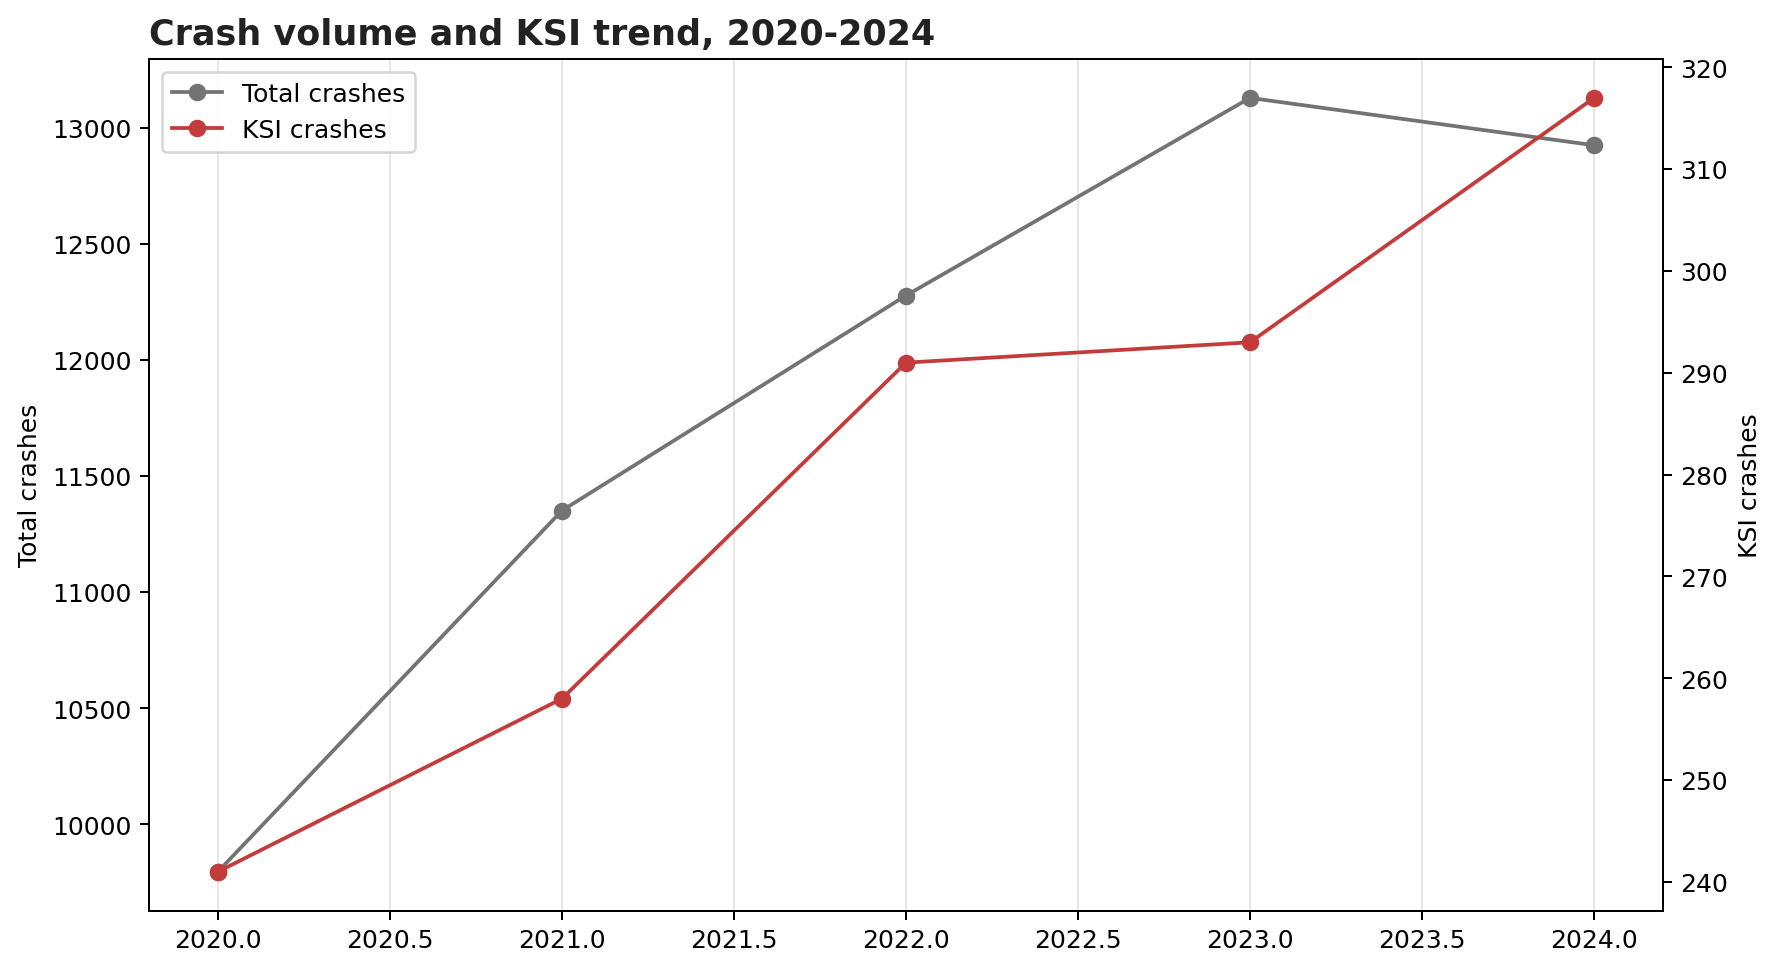

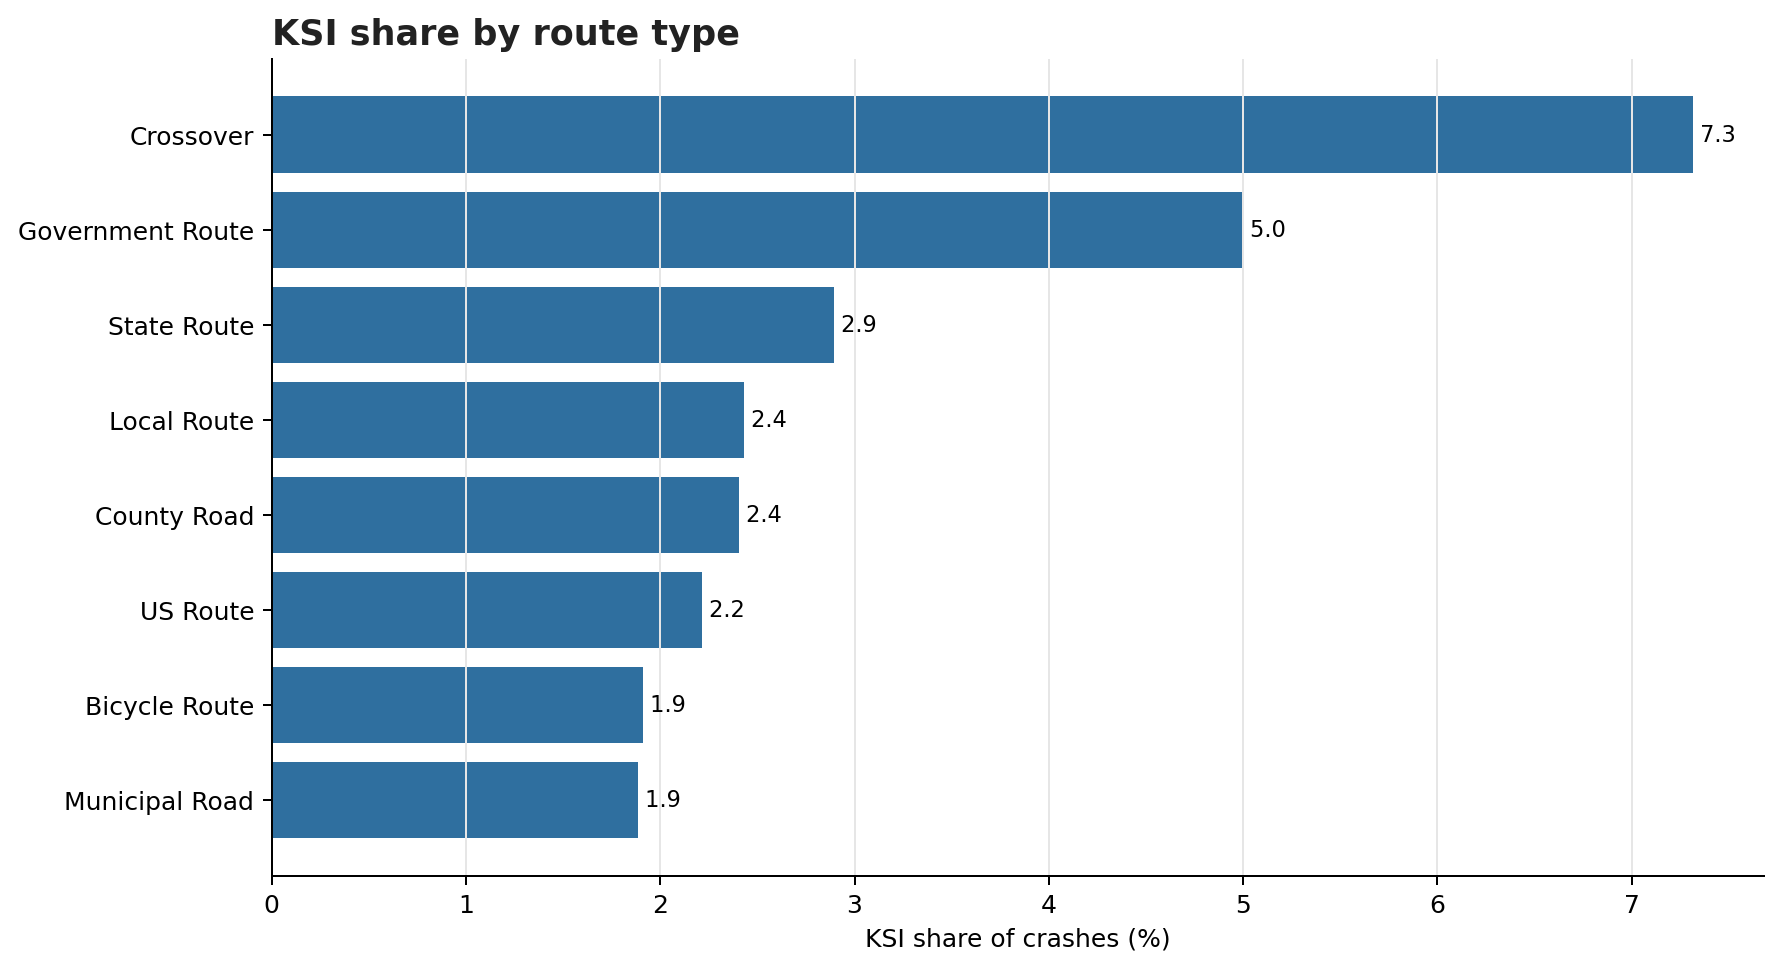

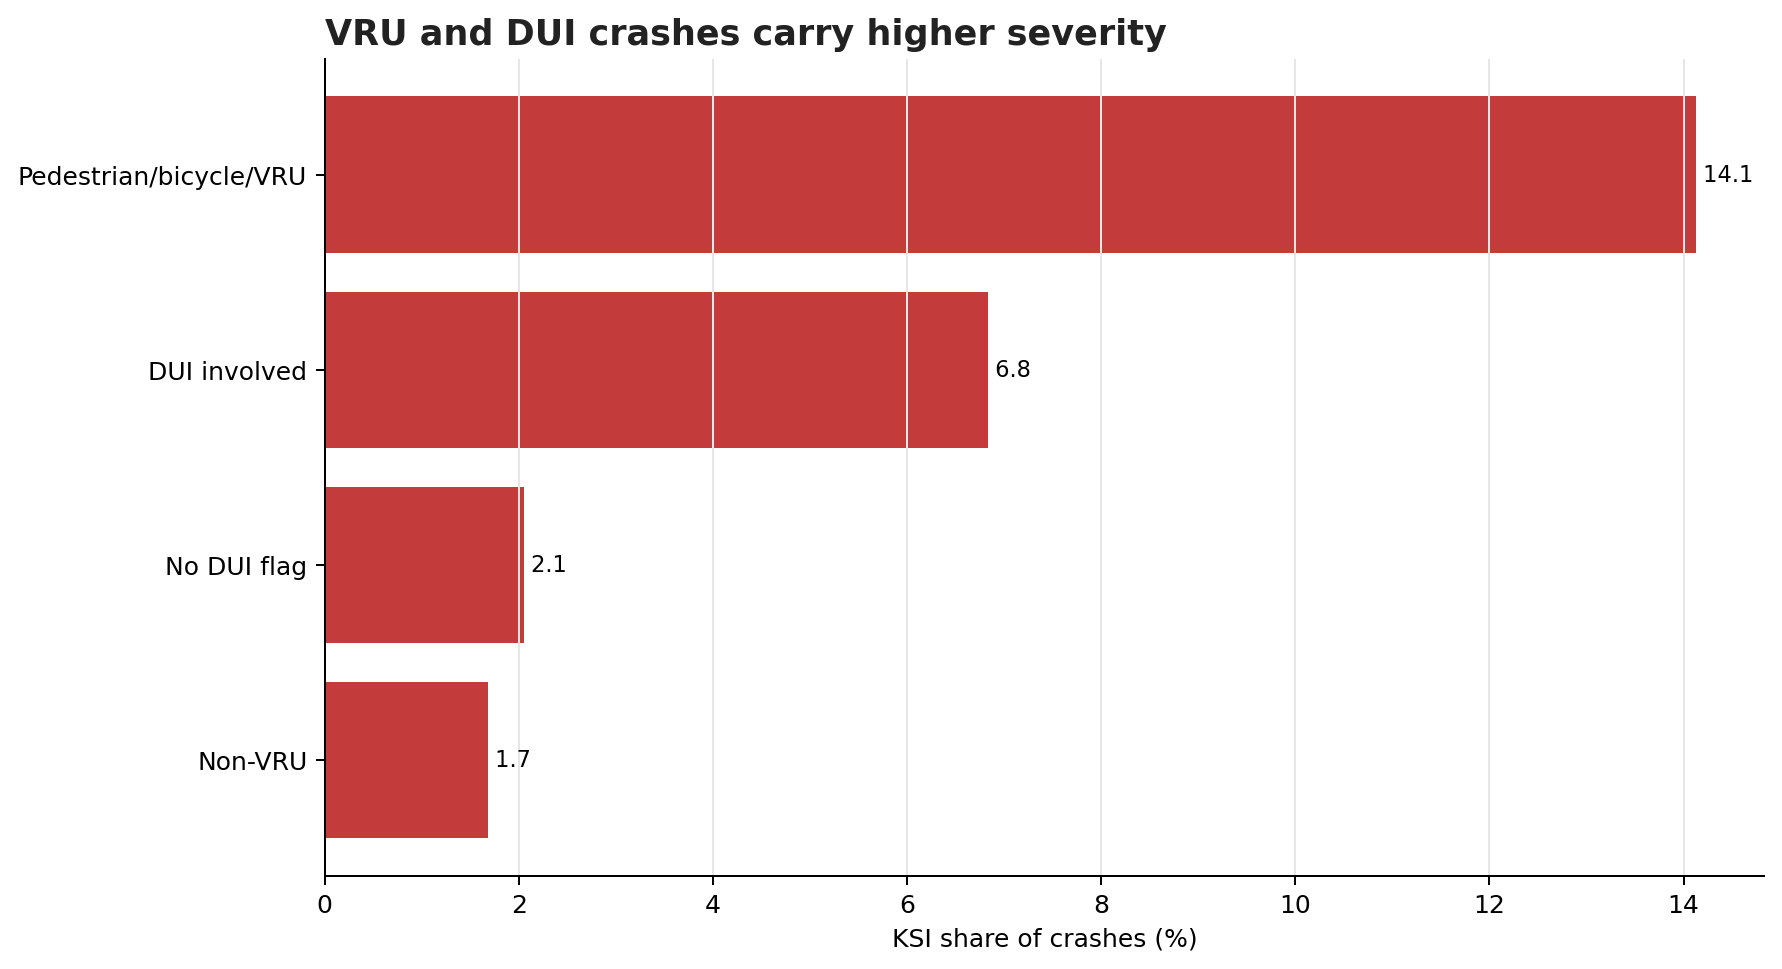

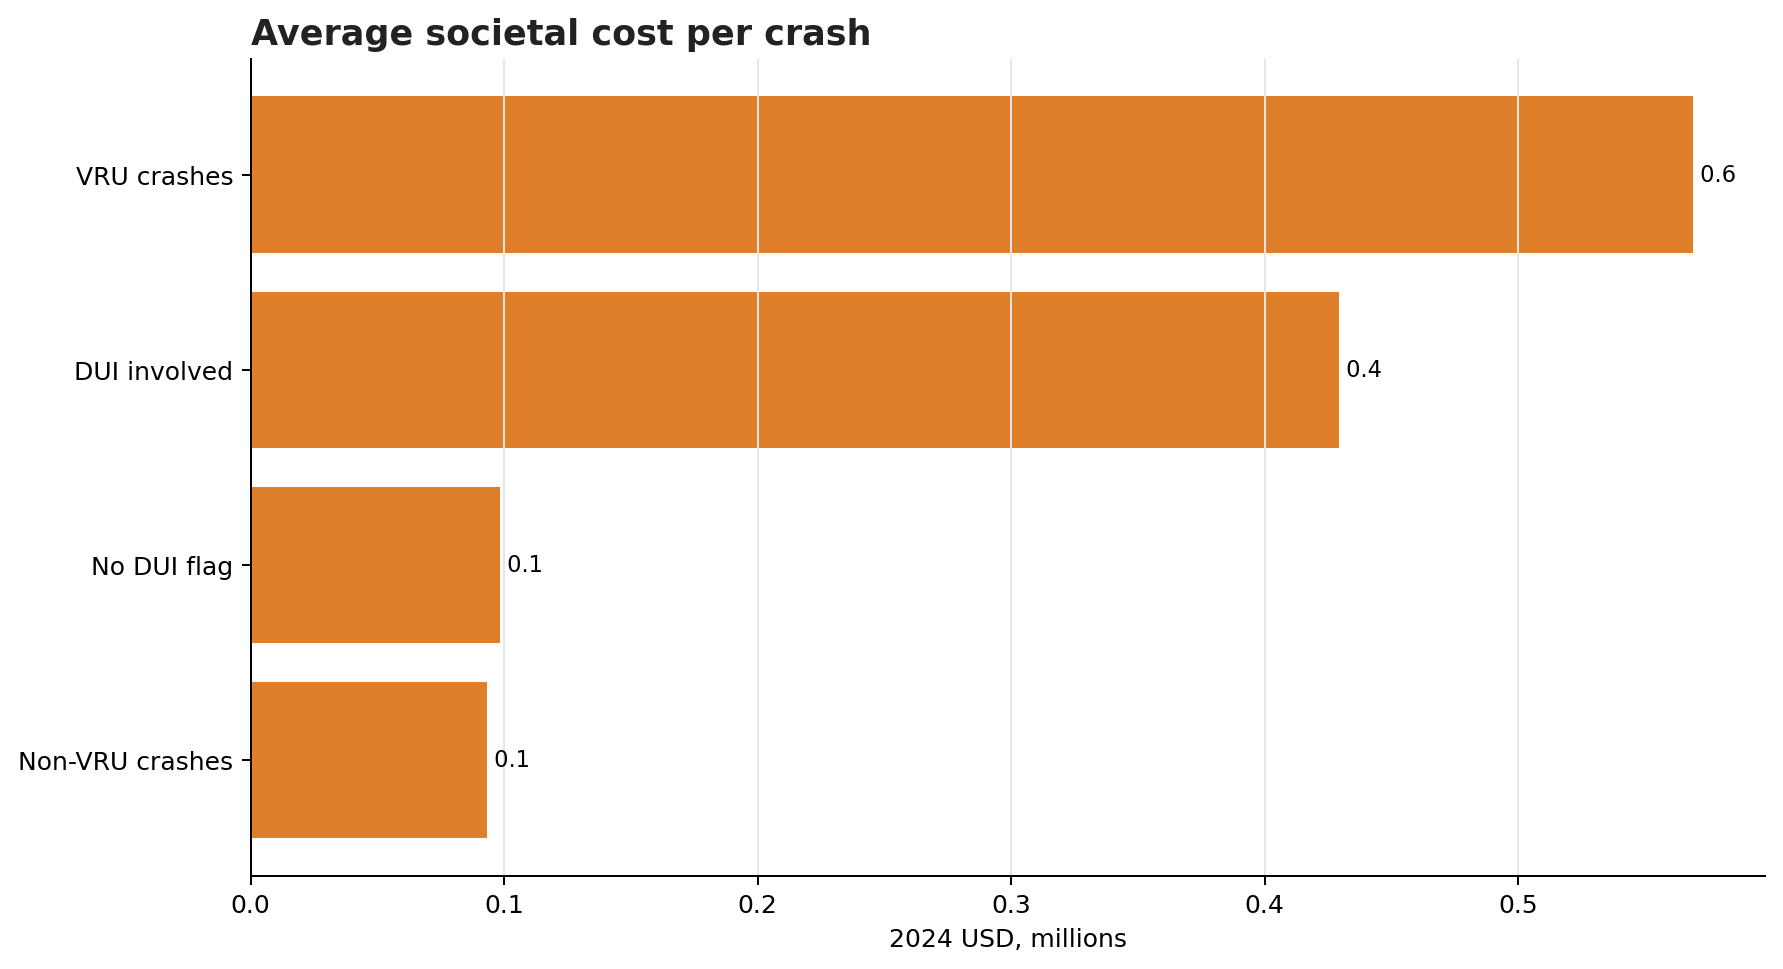

In [8]:
display(annual)

for chart in [
    "assets/chart_01_annual_crashes.png",
    "assets/chart_02_route_ksi_share.png",
    "assets/chart_03_vru_dui_ksi_share.png",
    "assets/chart_04_average_cost.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart)))

## 7. High-Injury Network And Exposure

**Finding.** The HIN ranks corridors by KSI burden and confirms that severe crashes are concentrated on a small share of roadway mileage. Exposure-adjusted rates add context by accounting for traffic volume and segment length.

,seg_label,length_mi,ksi_cnt,vru_ksi_cnt,ksi_disadv_cnt,AADT,ksi_rate_100M
0,State Hwy 355,28.978038,87,24,45,40962.0,4.016116
1,State Hwy 355,5.202092,46,6,38,29445.0,16.455284
2,Frederick Road,4.775080,42,6,34,29445.0,16.367947
3,Us Hwy 29,10.491864,40,10,14,67285.0,3.104747
4,State Hwy 193,6.665442,32,22,24,40304.0,6.526945
5,Columbia Pike,8.636896,30,8,14,67285.0,2.828671
6,State Hwy 193,7.184940,30,16,18,19542.0,11.707555
7,Woodfield Road,10.947119,28,2,0,11695.0,11.983815
8,State Hwy 124,10.937273,28,2,0,11695.0,11.994603
9,Us Hwy 29,10.489204,28,4,0,5770.0,25.349933


,seg_label,length_mi,ksi_cnt,vru_ksi_cnt,ksi_disadv_cnt,AADT,ksi_rate_100M
0,Indian Hills Dr,0.194424,2,1,0,1720.0,327.709095
1,Quince Orchard Road,0.091402,2,2,2,4732.0,253.375390
2,Halpine Road,0.318326,2,2,2,1695.0,203.107049
3,State Hwy 586,6.169986,20,10,16,882.0,201.379090
4,Veirs Mill Road,6.231985,20,10,16,882.0,199.375647
5,Selfridge Road,0.915670,2,1,2,865.0,138.360527
6,Walnut Avenue,0.082920,1,0,0,5095.0,129.698832
7,Quince Orchard Road,0.092509,1,0,1,4732.0,125.172424
8,Tucker Ln,1.946200,2,1,0,455.0,123.756570
9,Stoddard Pl,0.044471,1,0,1,11472.0,107.404463


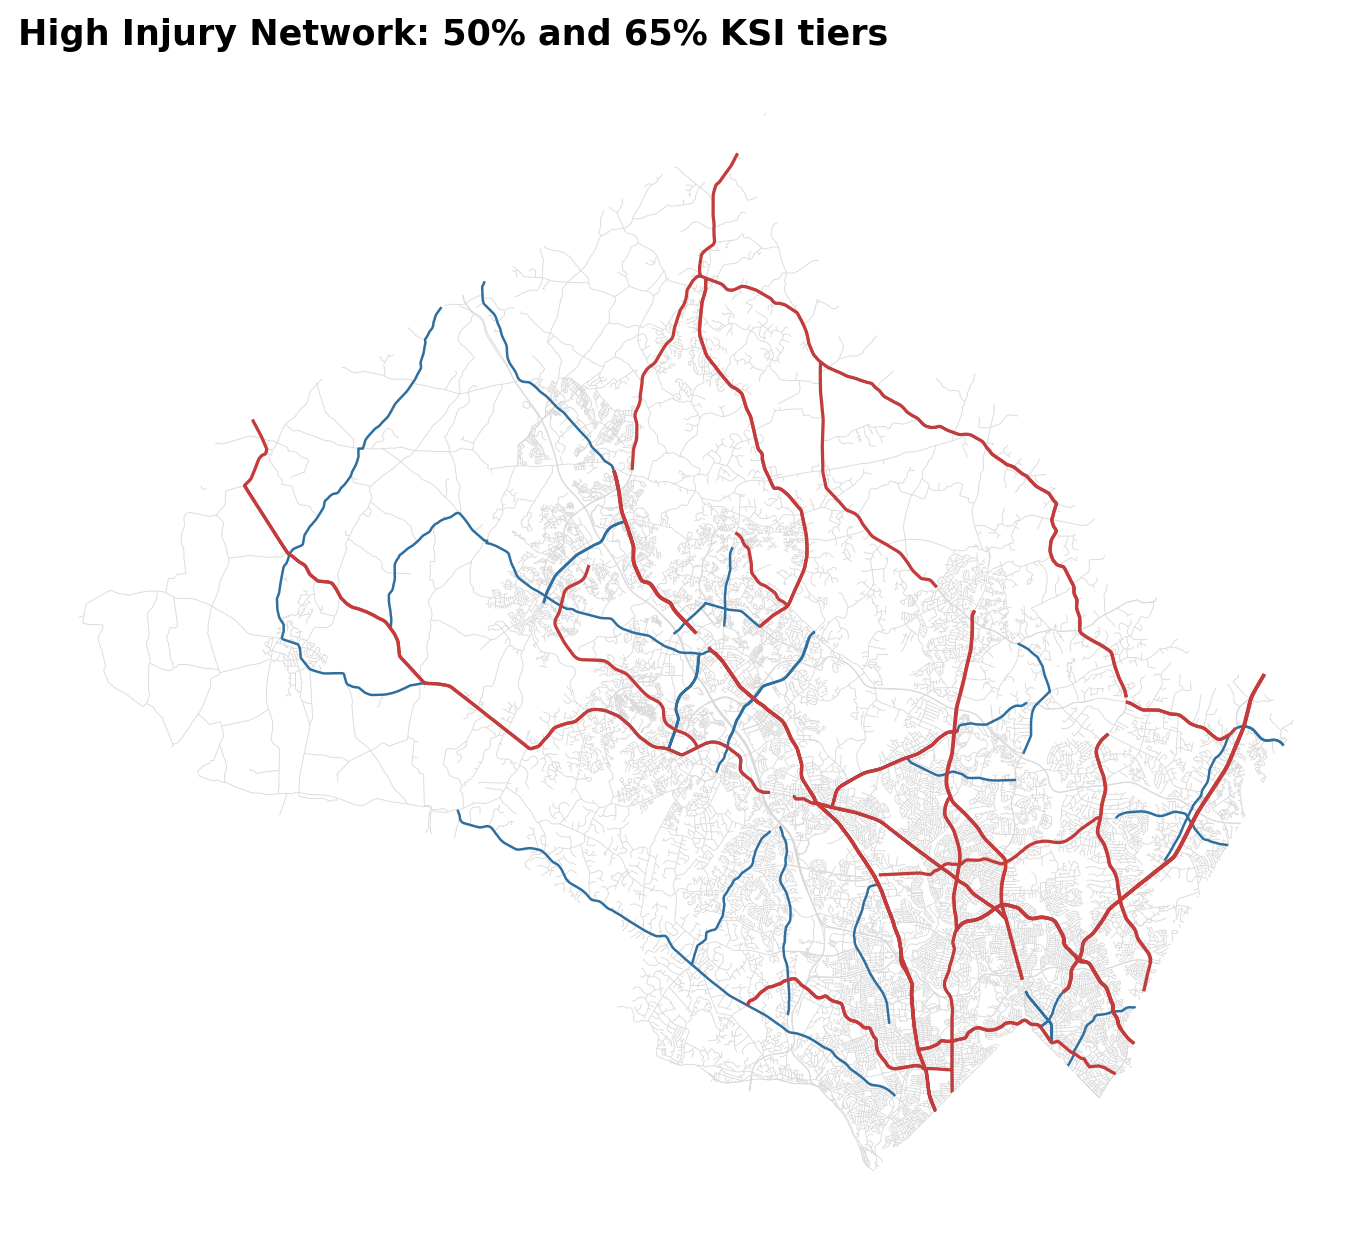

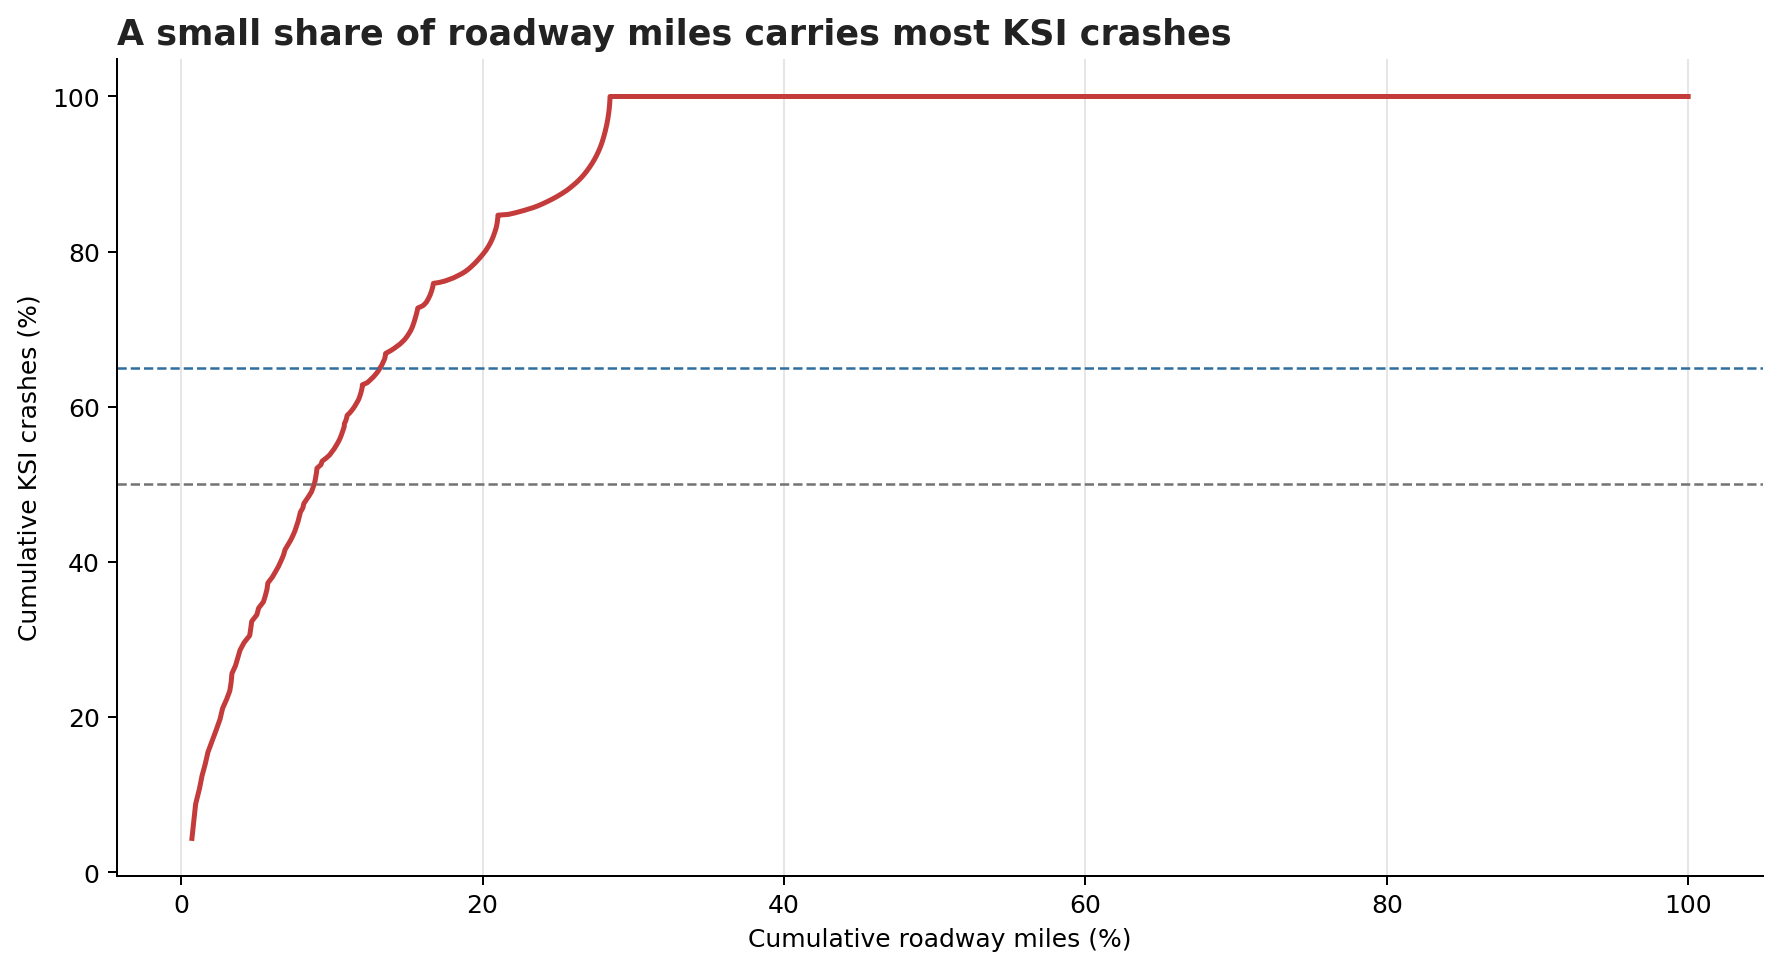

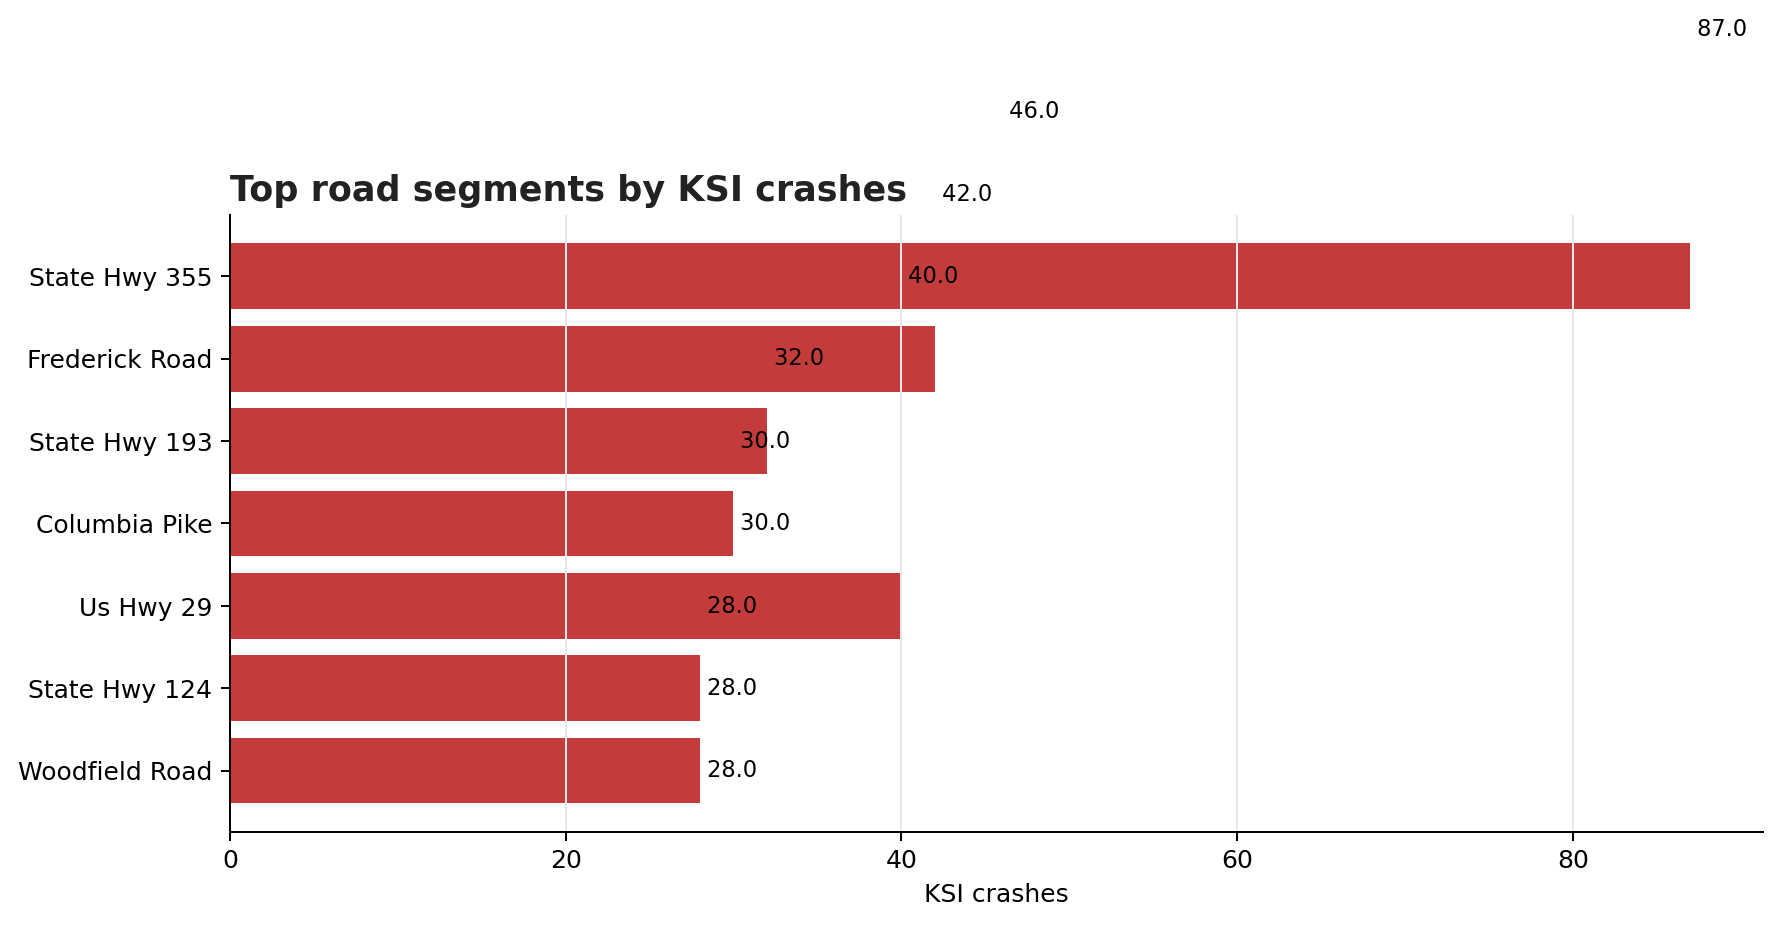

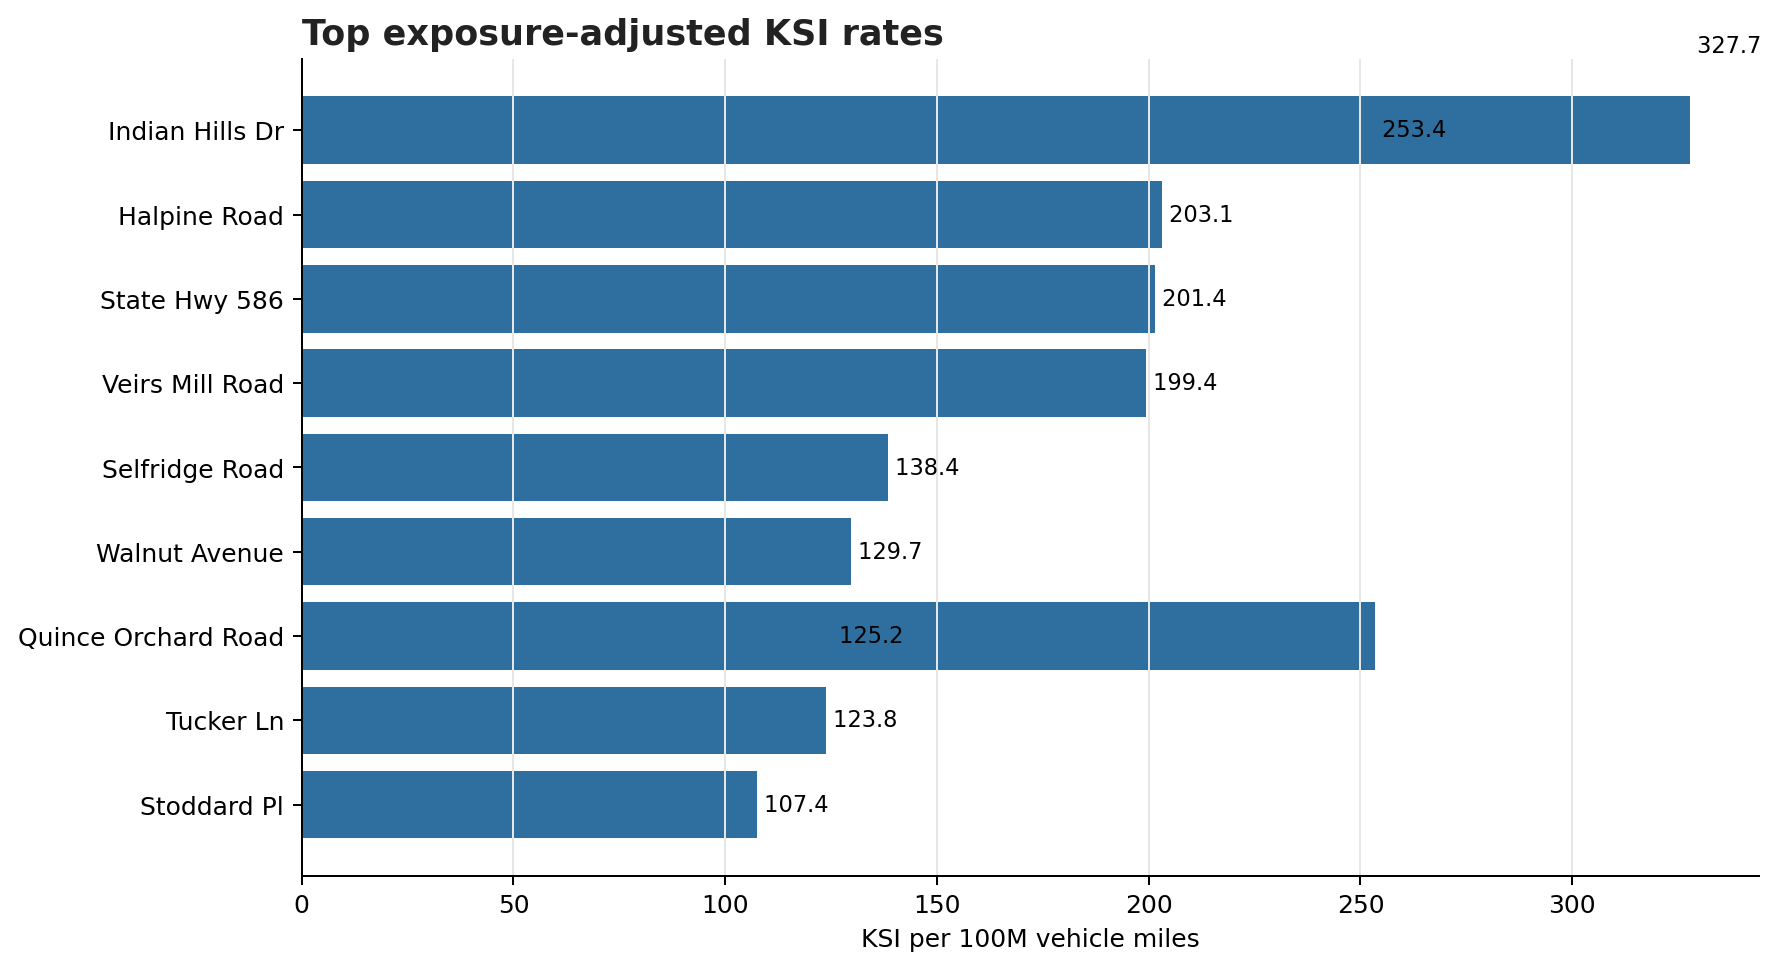

In [9]:
display(top_ksi)
display(top_exposure)

for chart in [
    "assets/chart_05_hin_map.png",
    "assets/chart_06_hin_concentration.png",
    "assets/chart_07_top_ksi_segments.png",
    "assets/chart_08_exposure_rate.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart)))

## 8. CEI-Aware Priority Scoring

**Objective.** Identify corridors where severe crash burden, vulnerable road user risk, exposure-adjusted risk, and disadvantaged CEI tract impacts overlap.

**Scoring formula.** `priority_score = normalized(1.00*KSI + 0.50*VRU_KSI + 0.25*KSI_rate + 0.25*KSI_in_disadvantaged_CEI_tracts)`.

,seg_label,length_mi,ksi_cnt,vru_ksi_cnt,ksi_disadv_cnt,AADT,ksi_rate_100M,priority_score
0,State Hwy 355,28.978038,87,24,45,40962.0,4.016116,1.000000
1,State Hwy 193,6.665442,32,22,24,40304.0,6.526945,0.550158
2,State Hwy 355,5.202092,46,6,38,29445.0,16.455284,0.500495
3,Frederick Road,4.775080,42,6,34,29445.0,16.367947,0.461554
4,State Hwy 193,7.184940,30,16,18,19542.0,11.707555,0.448981
5,Us Hwy 29,10.491864,40,10,14,67285.0,3.104747,0.426824
6,State Hwy 586,6.169986,20,10,16,882.0,201.379090,0.388311
7,Veirs Mill Road,6.231985,20,10,16,882.0,199.375647,0.387439
8,Rockville Pike,7.021819,28,10,16,53542.0,4.080853,0.354907
9,Columbia Pike,8.636896,30,8,14,67285.0,2.828671,0.337369


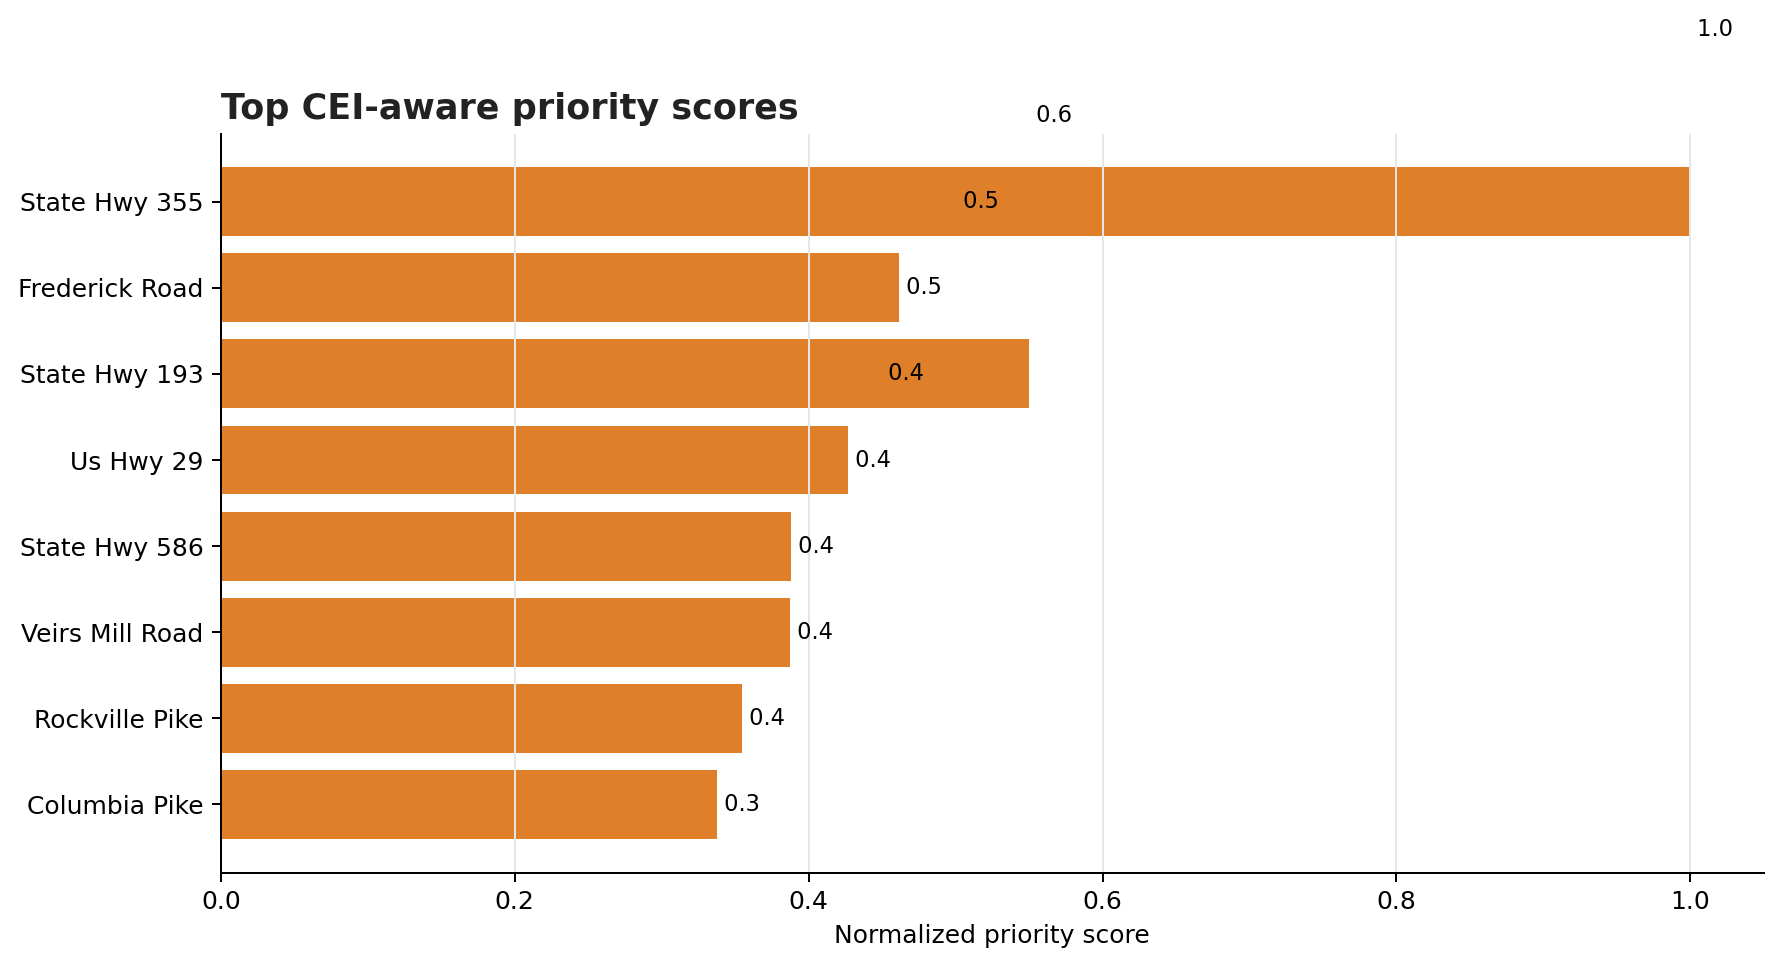

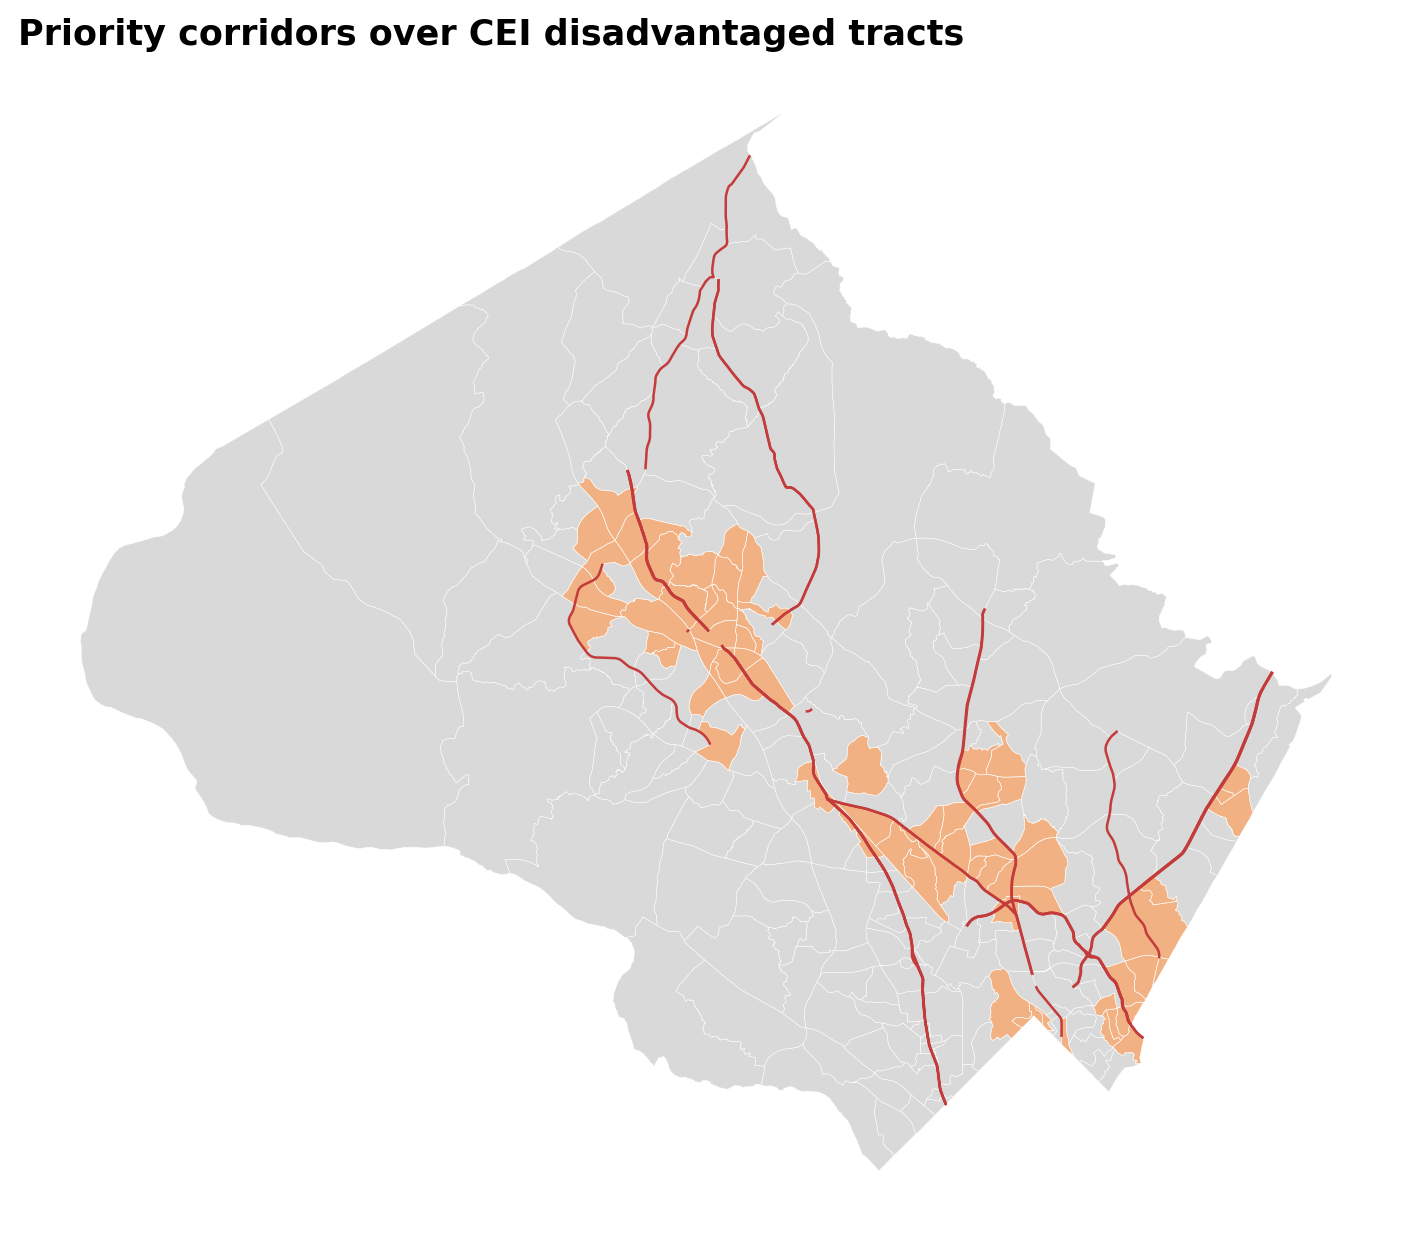

In [10]:
display(top_priority)

for chart in [
    "assets/chart_09_priority_score.png",
    "assets/chart_10_cei_priority_map.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart)))

## 9. Recommendations

1. Prioritize the top CEI-aware corridors for near-term safety investment.
2. Use quick-build treatments first where feasible: daylighting, leading pedestrian intervals, speed management, and crossing visibility.
3. Advance corridor redesigns on the Core HIN where KSI burden persists after low-cost treatments.
4. Re-score corridors every two to three years and track KSI, VRU KSI, CEI contribution, and exposure-adjusted rates.

## 10. Limitations

- Police-reported crash data can contain missing or inconsistent fields.
- AADT is used as a proxy for exposure and may not capture year-by-year traffic changes.
- Road matching uses nearest-road logic, so complex intersections and ramps require manual review before project design.
- CEI is a planning equity indicator, not a substitute for community engagement.

## 11. References

- Montgomery County Open Data: Crash Reporting Incidents, Drivers, and Non-Motorists
- Maryland DOT State Highway Administration: Annual Average Daily Traffic
- U.S. Census Bureau: TIGER/Line Roads
- Montgomery County: Community Equity Index
- USDOT and FHWA: Safe System Approach and Proven Safety Countermeasures